In here, we will explore ensemble methods for machine learning, basically having a *group of predictors/ classifers* and then doing a majority voting

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=500, noise= 0.30, random_state= 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42)

voting_clf = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state= 42)), 
        ('rf', RandomForestClassifier(random_state= 42)), 
        ('svc', SVC(random_state= 42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [2]:
voting_clf.estimators

[('lr', LogisticRegression(random_state=42)),
 ('rf', RandomForestClassifier(random_state=42)),
 ('svc', SVC(random_state=42))]

In [8]:
voting_clf.named_estimators_.items()

dict_items([('lr', LogisticRegression(random_state=42)), ('rf', RandomForestClassifier(random_state=42)), ('svc', SVC(random_state=42))])

In [9]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


so each of them individually has an **86-89%** accuracy on the test set...

In [10]:
voting_clf.score(X_test, y_test)

0.912

voting classifer outperforms them all

In [11]:
voting_clf.predict(X_test[:1])


array([1], dtype=int64)

In [12]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64)]

The voting classifier right performs what we call **hard** voting... just a majority of votes

**soft** voting is when it gets the probabilities from each classifer and avergaes them out to give the predicition.. Higher probability for a classifier gets a *higher weight*

In [14]:
voting_clf.voting= "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

so, soft voting outperforms hard voting.. may not be always true (overfitting) but worth a look

So far, we have aggregated predictors... train each on the training set and then vote a majority

Another key technique is bagging/ pasting.. in here, we train, perhaps even the same predictors on different random subsets of the training set

only diff is, **Bagging** allows for sampling **with replacement** (where an instance can be repeated in any one subset training a particular classifier) while in **Pasting**, that's not allowed

**Bagging/ Pasting**

In [79]:
#Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs= -1, random_state=
                          42) ## n_jobs= -1 tells it to use all available CPU cores
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

In [80]:
#Pasting
past_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs= -1, bootstrap= False,random_state=42)
past_clf.fit(X_train, y_train)

BaggingClassifier(bootstrap=False, estimator=DecisionTreeClassifier(),
                  max_samples=100, n_estimators=500, n_jobs=-1,
                  random_state=42)

In [22]:
dec_tree= DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [85]:
def plot_decision_boundary(clf, X, y, axes): 
    xmin= X_train[:,0].min()
    xmax= X_train[:,0].max()
    ymin= X_train[:,1].min()
    ymax= X_train[:,1].max()

    axes= [xmin, xmax, ymin, ymax]
    
    x1, x2= np.meshgrid(np.linspace(axes[0], axes[1], 100), np.linspace(axes[2], axes[3], 100))
    X_new= np.c_[x1.ravel(), x2.ravel()]
    y_pred= clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha= 0.3, cmap= "Wistia")
    plt.contour(x1, x2, y_pred, cmap = "Greys", alpha= 0.8)

    colors = ["#78785c", "#c47b27"]
    markers= ("o", "^")

    for idx in (0,1):
        plt.plot(X[:,0][y==idx], X[:,1][y==idx],alpha= 0.5, color= colors[idx], marker= markers[idx], linestyle= "none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation= 0)

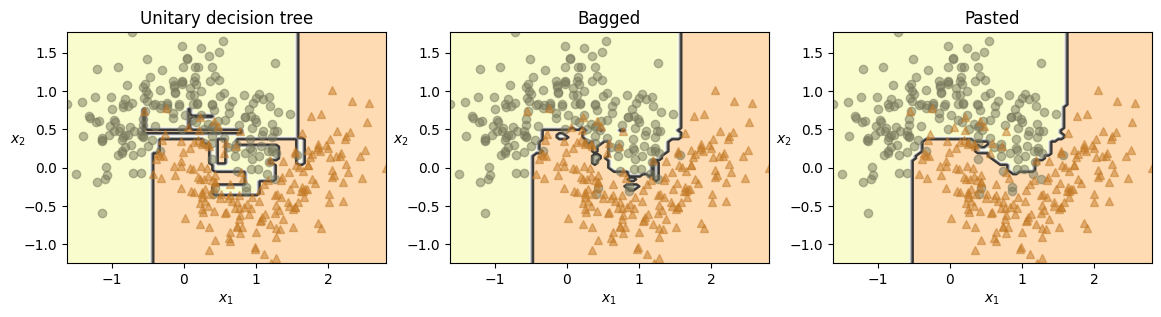

In [86]:
fig, axes= plt.subplots(1,3, figsize = (14,3))

plt.sca(axes[0])
plot_decision_boundary(dec_tree, X_train, y_train, axes)
plt.title("Unitary decision tree")

plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train, axes)
plt.title("Bagged")

plt.sca(axes[2])
plot_decision_boundary(past_clf, X_train, y_train, axes)
plt.title("Pasted")

plt.show()

You can see how both Bagging and Pasting are set to generalize much better than a single decision tree, but amongst the two it's little variation on the grooves... it's likely to keep chopping and changing between who wins over there

In [82]:
bag_clf= BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score= True, n_jobs= -1, random_state=
                          42) 
bag_clf.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                  n_jobs=-1, oob_score=True, random_state=42)

In [83]:
bag_clf.oob_score_ ## out of bag evaluations.. on the instances a predictor was'nt trained on

0.896

In [84]:
from sklearn.metrics import accuracy_score
y_pred_bagged= bag_clf.predict(X_test)
accuracy_score(y_test, y_pred_bagged)

0.92

In [81]:
y_pred_pasted= past_clf.predict(X_test)
accuracy_score(y_test, y_pred_pasted)

0.92

Damn..

### Random Patches and Subspaces